# Practical Exercise 2 - Task 3
# Conditional GAN (CGAN) on MNIST using PyTorch

In this notebook, we extend the Vanilla GAN into a Conditional GAN (CGAN).

We will:
1. Load the MNIST dataset
2. Build a conditional Generator and Discriminator
3. Train the CGAN using image-label pairs
4. Generate digit images conditioned on selected labels

In [1]:
# Standard library imports
import os
import random
from pathlib import Path
from datetime import datetime

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb

## General setup

In [2]:
# General experiment setup

LOG_WANDB = True
SEED = 1

# Paths
NOTEBOOK_DIR = Path.cwd()          # e.g. .../src
PROJECT_DIR = NOTEBOOK_DIR.parent  # parent folder of src
WANDB_DIR = PROJECT_DIR
OUT_DIR = PROJECT_DIR / "out"
MODELS_DIR = PROJECT_DIR / "Models"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Enable cuDNN auto-tuner for fixed-size inputs
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# Data loading settings
PIN_MEMORY = True if torch.cuda.is_available() else False
NUM_WORKERS = 4

# CPU optimization
torch.set_num_threads(8)
torch.set_num_interop_threads(8)

Using device: cuda


## Configuration

In [3]:
# Training configuration
config = {
    "batch_size": 128,
    "latent_dim": 100,
    "num_classes": 10,
    "g_hidden_dim": 128,
    "d_hidden_dim": 128,
    "image_dim": 28 * 28,
    "g_lr": 1e-3,
    "d_lr": 1e-3,
    "epochs": 100,
    "jupyter_plot_interval": 10,
    "wandb_image_interval": 1,
    "optimizer": "Adam",
    "betas": (0.9, 0.999),
    "dataset": "MNIST",
    "model": "Conditional GAN",
    "seed": SEED
}

config

{'batch_size': 128,
 'latent_dim': 100,
 'num_classes': 10,
 'g_hidden_dim': 128,
 'd_hidden_dim': 128,
 'image_dim': 784,
 'g_lr': 0.001,
 'd_lr': 0.001,
 'epochs': 100,
 'jupyter_plot_interval': 10,
 'wandb_image_interval': 1,
 'optimizer': 'Adam',
 'betas': (0.9, 0.999),
 'dataset': 'MNIST',
 'model': 'Conditional GAN',
 'seed': 1}

## Helper function for readable checkpoint names

In [4]:
# Build a readable file name for checkpoints
def build_model_name(config, task_name="task3_cgan", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return (
        f"{task_name}"
        f"_ep{config['epochs']}"
        f"_bs{config['batch_size']}"
        f"_glr{config['g_lr']}"
        f"_dlr{config['d_lr']}"
        f"_gh{config['g_hidden_dim']}"
        f"_dh{config['d_hidden_dim']}"
        f"_seed{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )

## Initialize Weights & Biases

In [5]:
# Shared W&B settings
WANDB_ENTITY = "d7047e-group12"
WANDB_PROJECT = "Lab2"

wandb_kwargs = dict(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="Task3 - Conditional GAN MNIST",
    tags=["Task 3", "CGAN", "GAN", "MNIST"],
    dir=str(WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

wandb.login()
wandb.init(**wandb_kwargs)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Load MNIST dataset

In [6]:
# Transform pipeline for MNIST
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# DataLoader handles batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 468


## Visualize a few real images

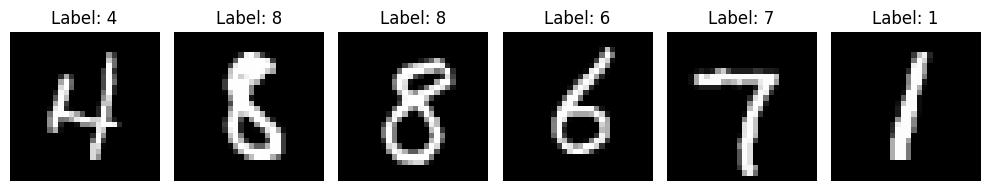

In [7]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Helper function for one-hot labels

In [8]:
# Convert integer labels to one-hot vectors
def to_one_hot(labels, num_classes):
    return torch.nn.functional.one_hot(labels, num_classes=num_classes).float()

## Define the conditional Generator

In [9]:
# Conditional Generator
# Input: noise vector + one-hot label
# Output: generated image vector of size 784

class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes, hidden_dim, image_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim),
            nn.Sigmoid()
        )

    def forward(self, z, y):
        zy = torch.cat([z, y], dim=1)
        return self.model(zy)

## Define the conditional Discriminator

In [10]:
# Conditional Discriminator
# Input: image vector + one-hot label
# Output: probability that the image is real

class Discriminator(nn.Module):
    def __init__(self, image_dim, num_classes, hidden_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        xy = torch.cat([x, y], dim=1)
        return self.model(xy)

## Initialize models

In [11]:
# Create model instances and move them to device
G = Generator(
    latent_dim=config["latent_dim"],
    num_classes=config["num_classes"],
    hidden_dim=config["g_hidden_dim"],
    image_dim=config["image_dim"]
).to(device)

D = Discriminator(
    image_dim=config["image_dim"],
    num_classes=config["num_classes"],
    hidden_dim=config["d_hidden_dim"]
).to(device)

print(G)
print()
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=110, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=794, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


## Define the loss function and optimizers

In [12]:
# Binary cross entropy loss for Conditional GAN
criterion = nn.BCELoss()

# Separate optimizers for Generator and Discriminator
g_optimizer = optim.Adam(
    G.parameters(),
    lr=config["g_lr"],
    betas=config["betas"]
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=config["d_lr"],
    betas=config["betas"]
)

## Helper function to visualize class-conditional samples

In [13]:
# Display generated images for a selected digit class
def show_generated_images(generator, latent_dim, digit, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        labels = torch.full((num_images,), digit, dtype=torch.long, device=device)
        labels_one_hot = to_one_hot(labels, config["num_classes"])

        fake_images = generator(z, labels_one_hot).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    generator.train()

## Helper function for W&B image logging

In [14]:
# Create a matplotlib figure for W&B image logging
def make_generated_figure(generator, latent_dim, digit, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        labels = torch.full((num_images,), digit, dtype=torch.long, device=device)
        labels_one_hot = to_one_hot(labels, config["num_classes"])

        fake_images = generator(z, labels_one_hot).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    generator.train()
    return fig

## Helper function to save class-conditional samples

In [15]:
# Save generated samples for a selected digit class
def save_generated_grid(generator, latent_dim, digit, save_path, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        labels = torch.full((num_images,), digit, dtype=torch.long, device=device)
        labels_one_hot = to_one_hot(labels, config["num_classes"])

        fake_images = generator(z, labels_one_hot).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

    generator.train()

## Train the Conditional GAN

Epoch [1/100] | D_loss: 0.2259 | G_loss: 4.5207
Epoch [2/100] | D_loss: 0.0606 | G_loss: 5.6488
Epoch [3/100] | D_loss: 0.0972 | G_loss: 5.0562
Epoch [4/100] | D_loss: 0.1470 | G_loss: 4.2462
Epoch [5/100] | D_loss: 0.1407 | G_loss: 4.8889
Saved generated samples to: /root/D7047E/Lab2/out/task3_cgan_digit_3_epoch_5.png
Epoch [6/100] | D_loss: 0.1860 | G_loss: 4.7769
Epoch [7/100] | D_loss: 0.2082 | G_loss: 5.3924
Epoch [8/100] | D_loss: 0.2864 | G_loss: 5.0661
Epoch [9/100] | D_loss: 0.3928 | G_loss: 4.1693
Epoch [10/100] | D_loss: 0.4619 | G_loss: 3.8930


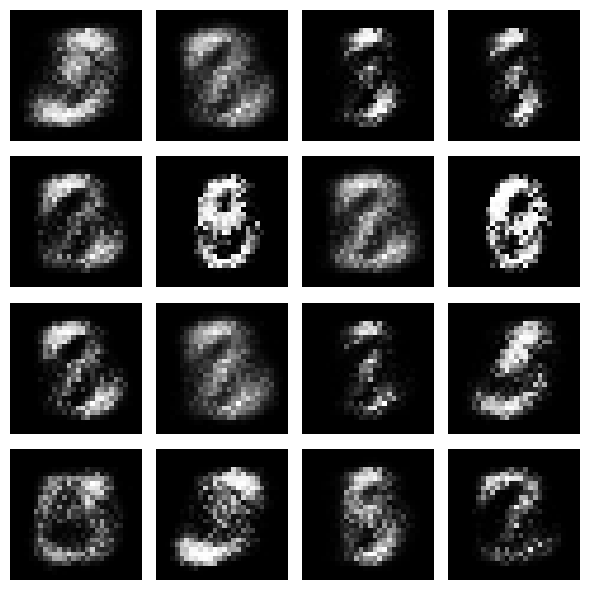

Saved generated samples to: /root/D7047E/Lab2/out/task3_cgan_digit_3_epoch_10.png
Epoch [11/100] | D_loss: 0.5977 | G_loss: 3.6003
Epoch [12/100] | D_loss: 0.7378 | G_loss: 3.7201
Epoch [13/100] | D_loss: 0.7690 | G_loss: 3.1806
Epoch [14/100] | D_loss: 0.7723 | G_loss: 2.8445
Epoch [15/100] | D_loss: 0.7141 | G_loss: 2.9594
Epoch [16/100] | D_loss: 0.6560 | G_loss: 2.8871
Epoch [17/100] | D_loss: 0.6779 | G_loss: 3.0909
Epoch [18/100] | D_loss: 0.8041 | G_loss: 2.9655
Epoch [19/100] | D_loss: 0.8771 | G_loss: 2.7246
Epoch [20/100] | D_loss: 0.8579 | G_loss: 2.5872


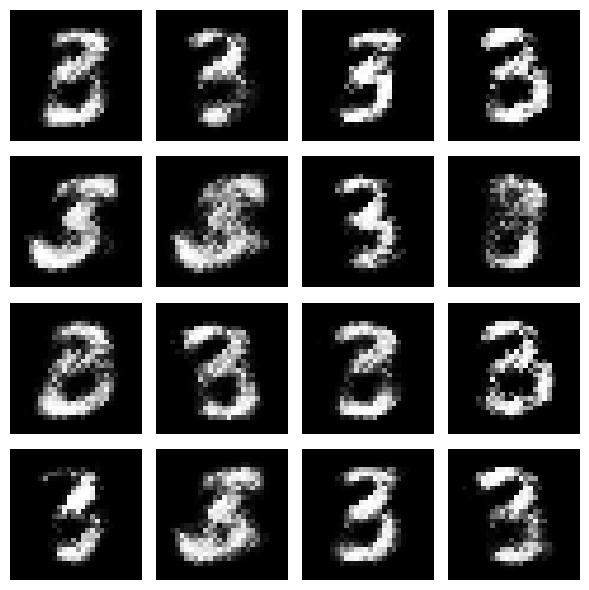

Epoch [21/100] | D_loss: 0.9169 | G_loss: 2.3602
Epoch [22/100] | D_loss: 0.8738 | G_loss: 2.3203
Epoch [23/100] | D_loss: 0.9118 | G_loss: 2.2300
Epoch [24/100] | D_loss: 0.9587 | G_loss: 2.1843
Epoch [25/100] | D_loss: 0.9605 | G_loss: 2.0842
Epoch [26/100] | D_loss: 0.8925 | G_loss: 2.2126
Epoch [27/100] | D_loss: 0.9220 | G_loss: 2.1136
Epoch [28/100] | D_loss: 0.8846 | G_loss: 2.0317
Epoch [29/100] | D_loss: 0.8654 | G_loss: 2.0711
Epoch [30/100] | D_loss: 0.8467 | G_loss: 2.0633


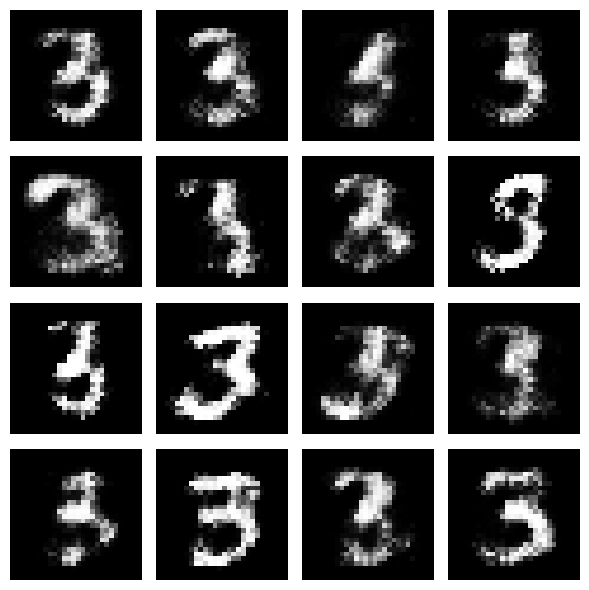

Epoch [31/100] | D_loss: 0.8766 | G_loss: 2.0964
Epoch [32/100] | D_loss: 0.8853 | G_loss: 2.1041
Epoch [33/100] | D_loss: 0.9241 | G_loss: 1.9715
Epoch [34/100] | D_loss: 0.9462 | G_loss: 1.9310
Epoch [35/100] | D_loss: 0.8914 | G_loss: 2.0251
Epoch [36/100] | D_loss: 0.9161 | G_loss: 1.9210
Epoch [37/100] | D_loss: 0.9343 | G_loss: 1.8686
Epoch [38/100] | D_loss: 0.8922 | G_loss: 1.8933
Epoch [39/100] | D_loss: 0.9139 | G_loss: 1.9083
Epoch [40/100] | D_loss: 0.9139 | G_loss: 1.8834


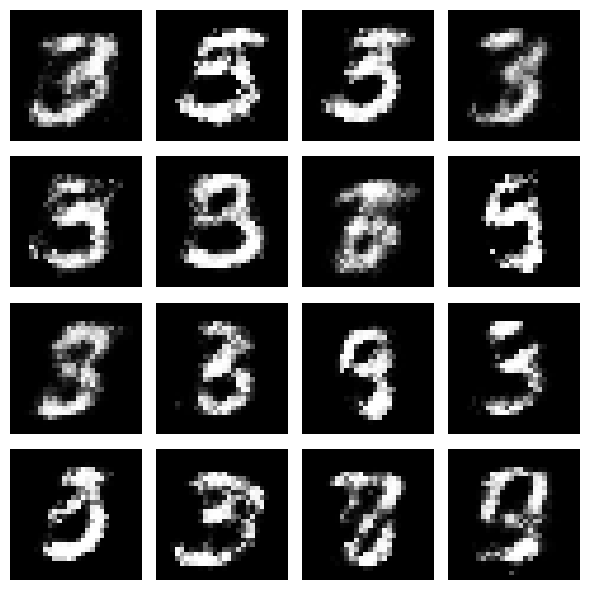

Epoch [41/100] | D_loss: 0.9258 | G_loss: 1.8034
Epoch [42/100] | D_loss: 0.9601 | G_loss: 1.8260
Epoch [43/100] | D_loss: 0.9356 | G_loss: 1.7637
Epoch [44/100] | D_loss: 0.9562 | G_loss: 1.7443
Epoch [45/100] | D_loss: 0.9291 | G_loss: 1.7638
Epoch [46/100] | D_loss: 0.9694 | G_loss: 1.7386
Epoch [47/100] | D_loss: 0.9280 | G_loss: 1.7967
Epoch [48/100] | D_loss: 0.9447 | G_loss: 1.7975
Epoch [49/100] | D_loss: 0.9729 | G_loss: 1.7142
Epoch [50/100] | D_loss: 0.9676 | G_loss: 1.7274


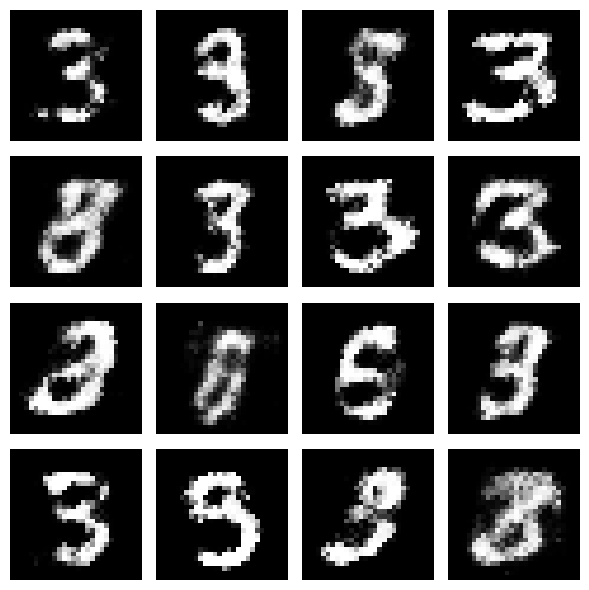

Saved generated samples to: /root/D7047E/Lab2/out/task3_cgan_digit_3_epoch_50.png
Epoch [51/100] | D_loss: 0.9737 | G_loss: 1.7369
Epoch [52/100] | D_loss: 0.9549 | G_loss: 1.7171
Epoch [53/100] | D_loss: 0.9650 | G_loss: 1.7306
Epoch [54/100] | D_loss: 0.9794 | G_loss: 1.6403
Epoch [55/100] | D_loss: 0.9723 | G_loss: 1.6573
Epoch [56/100] | D_loss: 0.9945 | G_loss: 1.5825
Epoch [57/100] | D_loss: 0.9840 | G_loss: 1.5950
Epoch [58/100] | D_loss: 0.9821 | G_loss: 1.6261
Epoch [59/100] | D_loss: 0.9736 | G_loss: 1.6117
Epoch [60/100] | D_loss: 0.9748 | G_loss: 1.5785


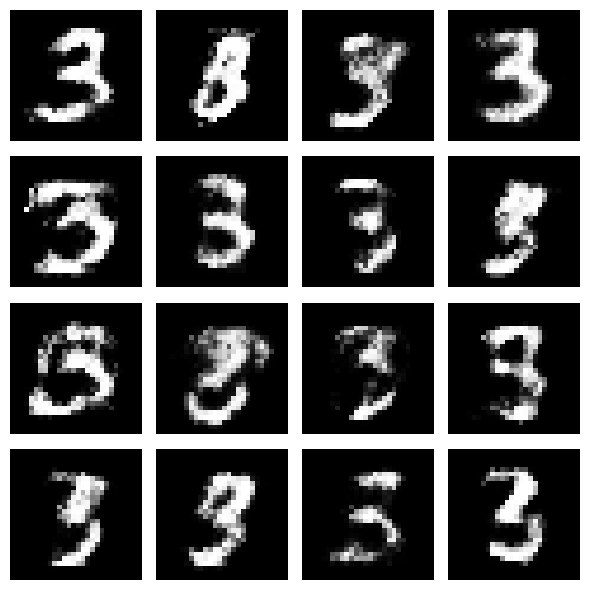

Epoch [61/100] | D_loss: 0.9701 | G_loss: 1.5593
Epoch [62/100] | D_loss: 0.9700 | G_loss: 1.5750
Epoch [63/100] | D_loss: 0.9871 | G_loss: 1.5934
Epoch [64/100] | D_loss: 0.9863 | G_loss: 1.5876
Epoch [65/100] | D_loss: 0.9825 | G_loss: 1.6199
Epoch [66/100] | D_loss: 0.9867 | G_loss: 1.5914
Epoch [67/100] | D_loss: 0.9872 | G_loss: 1.5828
Epoch [68/100] | D_loss: 0.9996 | G_loss: 1.5392
Epoch [69/100] | D_loss: 0.9917 | G_loss: 1.5345
Epoch [70/100] | D_loss: 0.9984 | G_loss: 1.5142


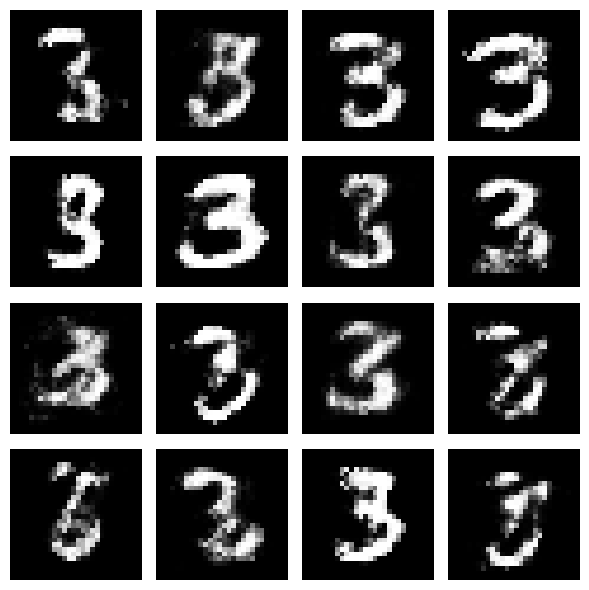

Epoch [71/100] | D_loss: 0.9751 | G_loss: 1.5217
Epoch [72/100] | D_loss: 0.9692 | G_loss: 1.5470
Epoch [73/100] | D_loss: 0.9697 | G_loss: 1.5682
Epoch [74/100] | D_loss: 0.9838 | G_loss: 1.5623
Epoch [75/100] | D_loss: 0.9748 | G_loss: 1.5719
Epoch [76/100] | D_loss: 0.9760 | G_loss: 1.5546
Epoch [77/100] | D_loss: 0.9776 | G_loss: 1.5265
Epoch [78/100] | D_loss: 0.9744 | G_loss: 1.5200
Epoch [79/100] | D_loss: 0.9880 | G_loss: 1.5487
Epoch [80/100] | D_loss: 0.9761 | G_loss: 1.5549


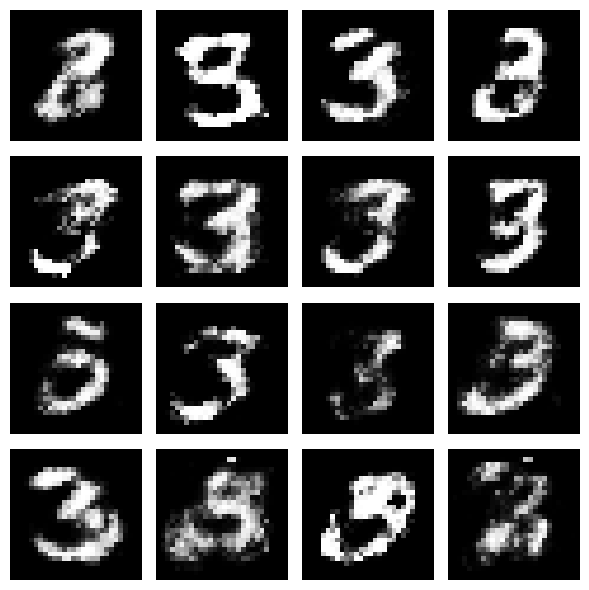

Epoch [81/100] | D_loss: 0.9665 | G_loss: 1.5850
Epoch [82/100] | D_loss: 0.9592 | G_loss: 1.5515
Epoch [83/100] | D_loss: 0.9591 | G_loss: 1.5446
Epoch [84/100] | D_loss: 0.9582 | G_loss: 1.5334
Epoch [85/100] | D_loss: 0.9653 | G_loss: 1.5738
Epoch [86/100] | D_loss: 0.9677 | G_loss: 1.6011
Epoch [87/100] | D_loss: 0.9665 | G_loss: 1.6091
Epoch [88/100] | D_loss: 0.9648 | G_loss: 1.5936
Epoch [89/100] | D_loss: 0.9709 | G_loss: 1.5405
Epoch [90/100] | D_loss: 0.9638 | G_loss: 1.5290


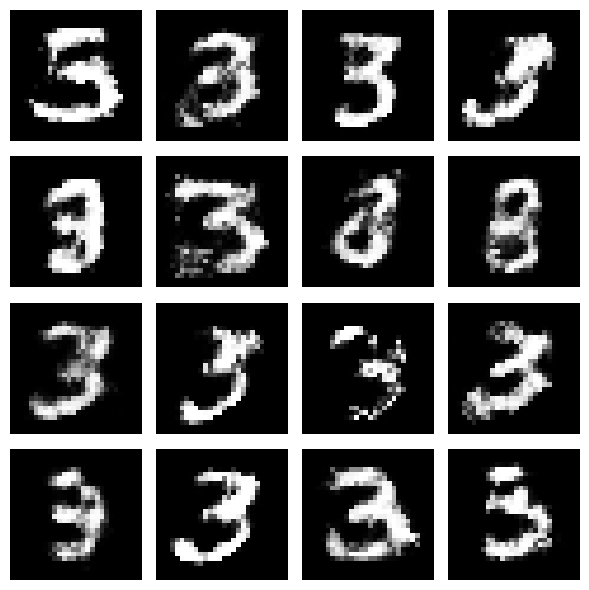

Epoch [91/100] | D_loss: 0.9701 | G_loss: 1.5086
Epoch [92/100] | D_loss: 0.9712 | G_loss: 1.5000
Epoch [93/100] | D_loss: 0.9766 | G_loss: 1.5019
Epoch [94/100] | D_loss: 0.9827 | G_loss: 1.5190
Epoch [95/100] | D_loss: 0.9728 | G_loss: 1.4884
Epoch [96/100] | D_loss: 0.9825 | G_loss: 1.4955
Epoch [97/100] | D_loss: 0.9850 | G_loss: 1.5017
Epoch [98/100] | D_loss: 0.9871 | G_loss: 1.4914
Epoch [99/100] | D_loss: 0.9870 | G_loss: 1.4671
Epoch [100/100] | D_loss: 0.9925 | G_loss: 1.4616


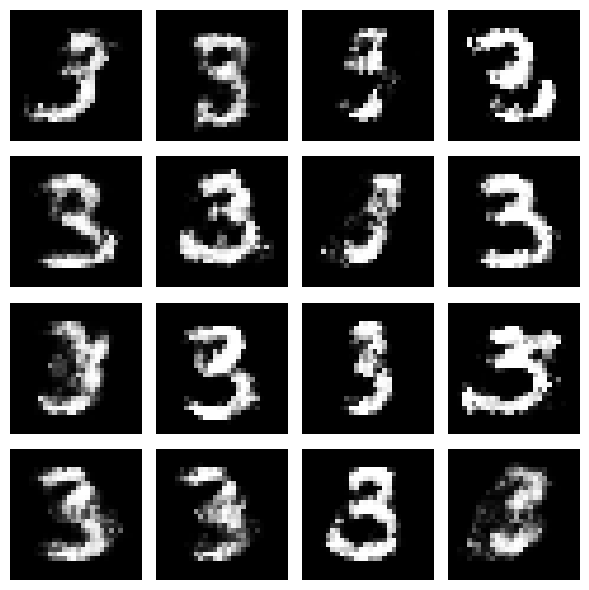

Saved generated samples to: /root/D7047E/Lab2/out/task3_cgan_digit_3_epoch_100.png


In [16]:
# Main training loop with epoch-level logging
# Also save generated samples at epochs 5, 10, 50, and 100

save_epochs = {5, 10, 50, 100}
tracked_digit = 3

for epoch in range(config["epochs"]):
    d_loss_list = []
    g_loss_list = []
    d_real_loss_list = []
    d_fake_loss_list = []

    for batch_idx, (real_images, real_labels_int) in enumerate(train_loader):
        # Prepare real images and labels
        real_images = real_images.view(-1, config["image_dim"]).to(device, non_blocking=True)
        real_labels_int = real_labels_int.to(device, non_blocking=True)
        real_labels_one_hot = to_one_hot(real_labels_int, config["num_classes"])

        batch_size = real_images.size(0)

        # Create real and fake labels for BCE
        real_targets = torch.ones(batch_size, 1, device=device)
        fake_targets = torch.zeros(batch_size, 1, device=device)

        # =========================================================
        # 1) Train the Discriminator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)

        # Use the same labels as the real batch for fake generation
        fake_images = G(z, real_labels_one_hot)

        d_real = D(real_images, real_labels_one_hot)
        d_fake = D(fake_images.detach(), real_labels_one_hot)

        d_real_loss = criterion(d_real, real_targets)
        d_fake_loss = criterion(d_fake, fake_targets)
        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # =========================================================
        # 2) Train the Generator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)

        fake_images = G(z, real_labels_one_hot)
        d_fake_for_g = D(fake_images, real_labels_one_hot)

        g_loss = criterion(d_fake_for_g, real_targets)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Store losses for epoch-level averaging
        d_loss_list.append(d_loss.item())
        g_loss_list.append(g_loss.item())
        d_real_loss_list.append(d_real_loss.item())
        d_fake_loss_list.append(d_fake_loss.item())

    # Compute average losses for the epoch
    avg_d_loss = np.mean(d_loss_list)
    avg_g_loss = np.mean(g_loss_list)
    avg_d_real_loss = np.mean(d_real_loss_list)
    avg_d_fake_loss = np.mean(d_fake_loss_list)

    # Print a clean epoch summary
    print(
        f"Epoch [{epoch + 1}/{config['epochs']}] | "
        f"D_loss: {avg_d_loss:.4f} | "
        f"G_loss: {avg_g_loss:.4f}"
    )

    # Log scalar metrics to W&B once per epoch
    wandb.log({
        "epoch": epoch + 1,
        "D_loss": avg_d_loss,
        "G_loss": avg_g_loss,
        "D_real_loss": avg_d_real_loss,
        "D_fake_loss": avg_d_fake_loss
    }, step=epoch + 1)

    # Log conditional images to W&B
    if (epoch + 1) % config["wandb_image_interval"] == 0:
        fig = make_generated_figure(
            generator=G,
            latent_dim=config["latent_dim"],
            digit=tracked_digit,
            num_images=16
        )

        wandb.log({
            "generated_samples_digit_3": wandb.Image(fig, caption=f"Epoch {epoch + 1}")
        }, step=epoch + 1)

        if (epoch + 1) % config["jupyter_plot_interval"] == 0:
            plt.show()

        plt.close(fig)

    # Save generated samples locally at selected epochs
    if (epoch + 1) in save_epochs:
        save_path = OUT_DIR / f"task3_cgan_digit_{tracked_digit}_epoch_{epoch + 1}.png"
        save_generated_grid(
            generator=G,
            latent_dim=config["latent_dim"],
            digit=tracked_digit,
            save_path=save_path,
            num_images=16
        )
        print(f"Saved generated samples to: {save_path}")

## Display final generated samples for a chosen digit

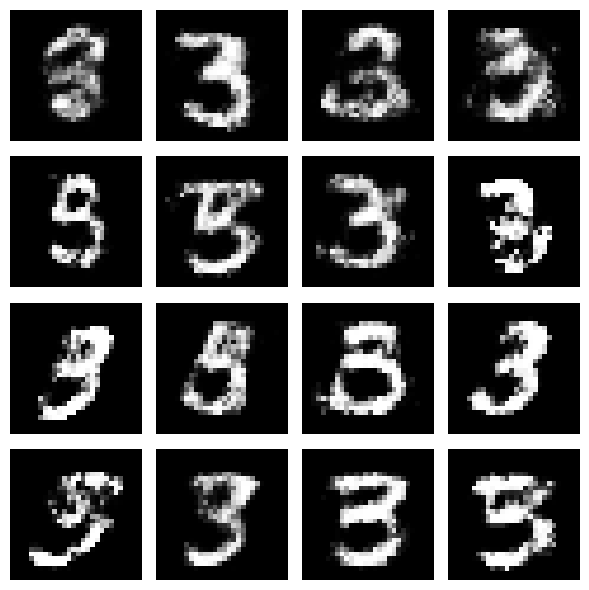

In [17]:
# Show final generated images for digit 3
show_generated_images(G, config["latent_dim"], digit=3, num_images=16)

## Generate one grid for each class from 0 to 9

Generated samples for digit 0


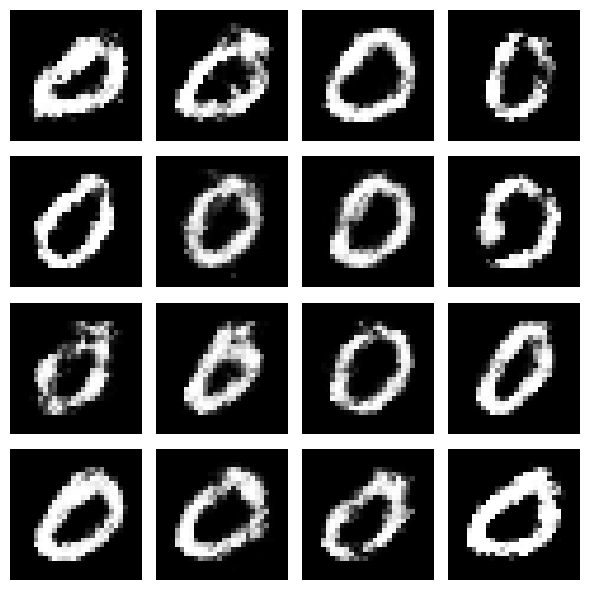

Generated samples for digit 1


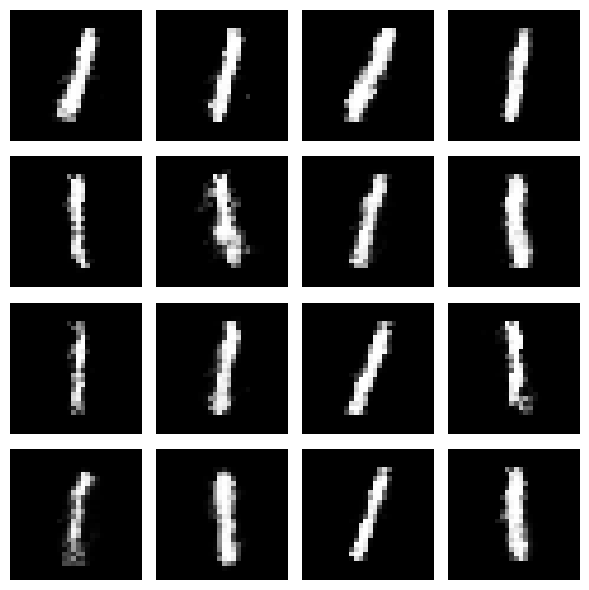

Generated samples for digit 2


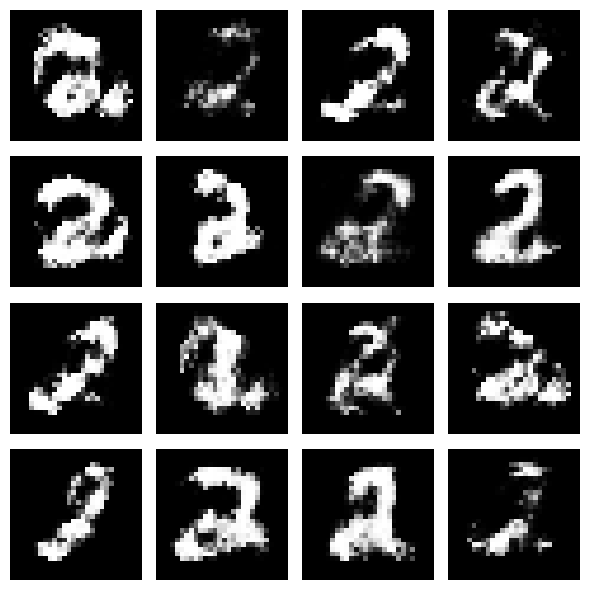

Generated samples for digit 3


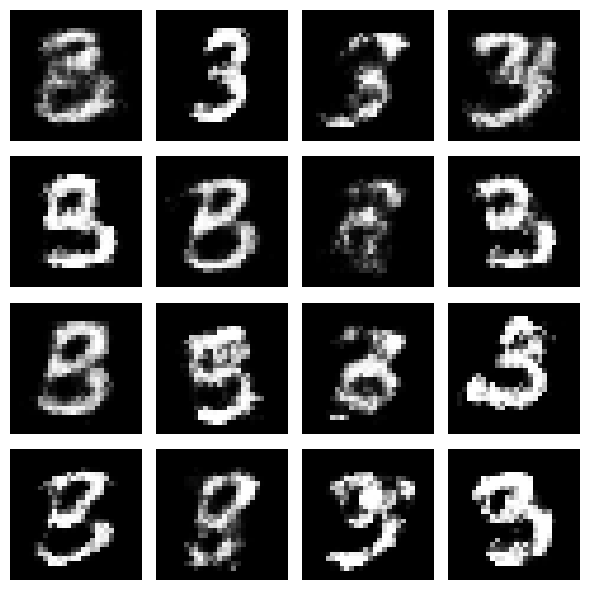

Generated samples for digit 4


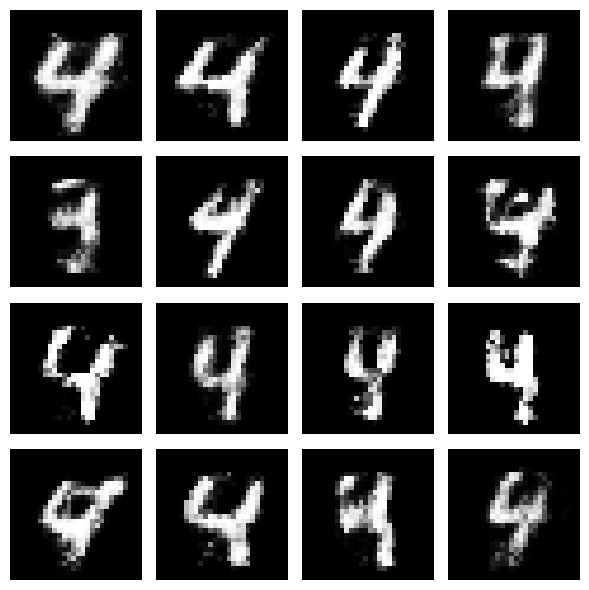

Generated samples for digit 5


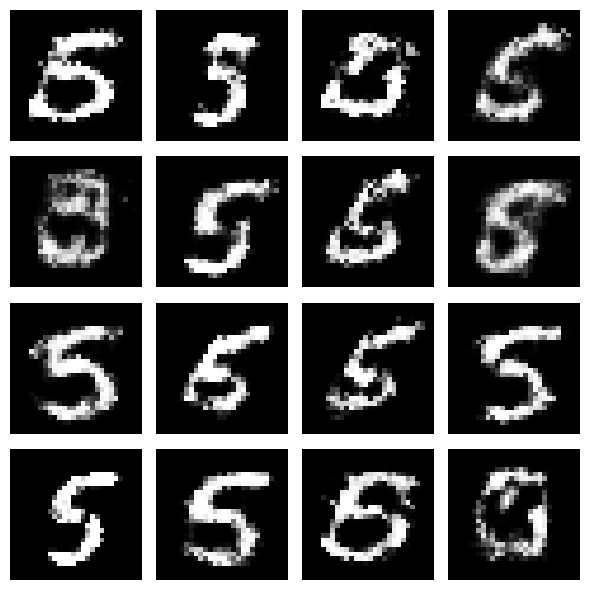

Generated samples for digit 6


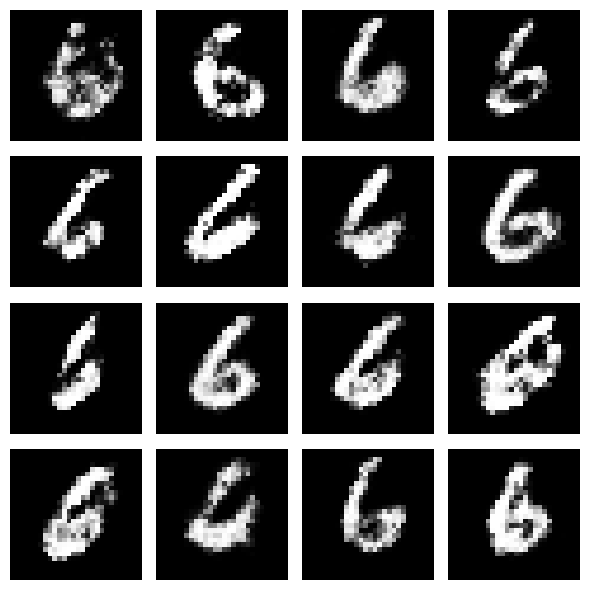

Generated samples for digit 7


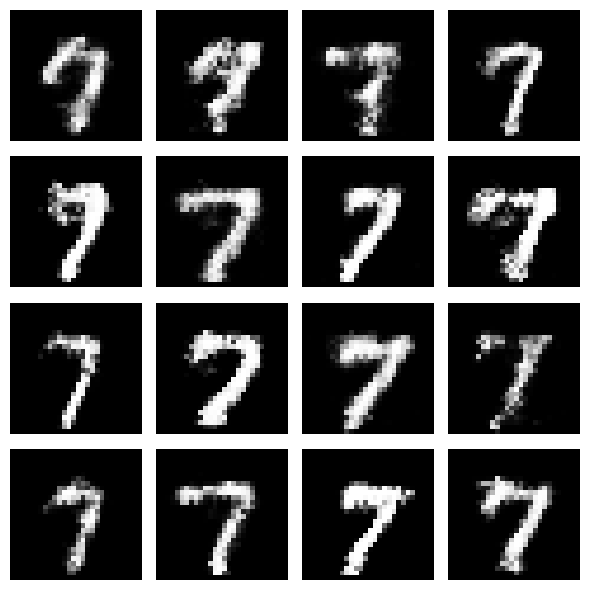

Generated samples for digit 8


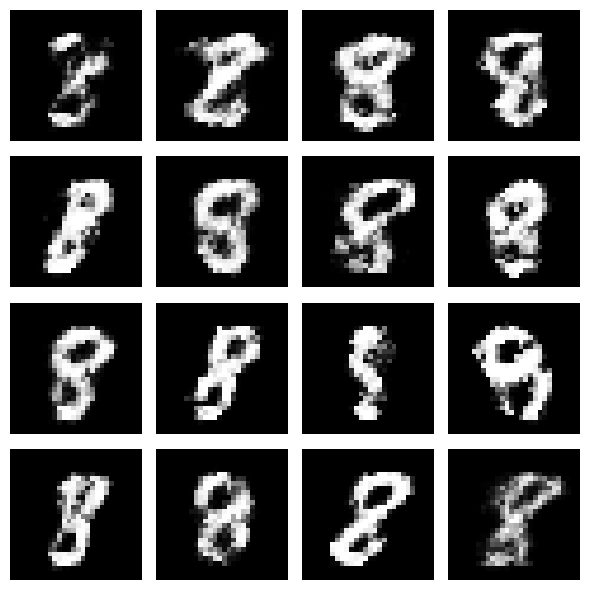

Generated samples for digit 9


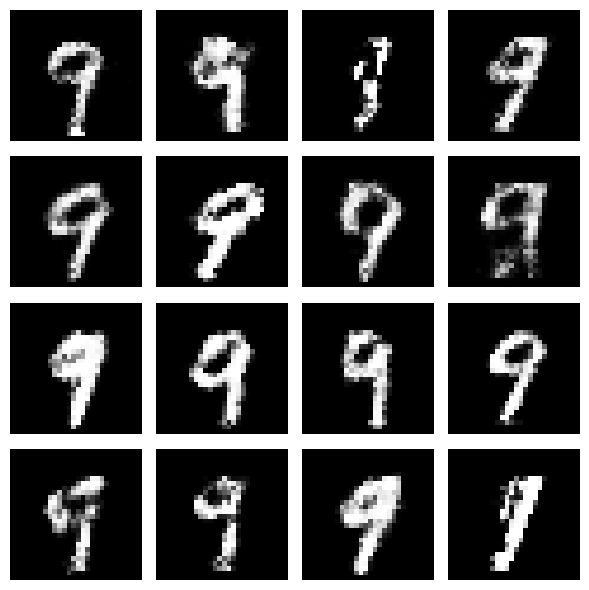

In [18]:
# Generate one grid per digit class
for digit in range(10):
    print(f"Generated samples for digit {digit}")
    show_generated_images(G, config["latent_dim"], digit=digit, num_images=16)

## Save trained models

In [19]:
# Save a full training checkpoint
checkpoint_name = build_model_name(config, task_name="task3_cgan")
checkpoint_path = MODELS_DIR / checkpoint_name

torch.save({
    "task": "Task 3",
    "model_type": config["model"],
    "dataset": config["dataset"],
    "epoch": config["epochs"],
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "g_optimizer_state_dict": g_optimizer.state_dict(),
    "d_optimizer_state_dict": d_optimizer.state_dict(),
    "config": config,
    "device_used": str(device),
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")

Checkpoint saved to: /root/D7047E/Lab2/Models/task3_cgan_ep100_bs128_glr0.001_dlr0.001_gh128_dh128_seed1_20260419_150010.pt


In [20]:
# Save Generator weights only
generator_name = build_model_name(config, task_name="task3_cgan_generator")
generator_path = MODELS_DIR / generator_name

torch.save(G.state_dict(), generator_path)

print(f"Generator weights saved to: {generator_path}")

Generator weights saved to: /root/D7047E/Lab2/Models/task3_cgan_generator_ep100_bs128_glr0.001_dlr0.001_gh128_dh128_seed1_20260419_150010.pt


## Finish the W&B run

In [21]:
wandb.finish()

D_fake_loss,▂▁▂▂▃▆▅▅▆▇▇▇▇▇▇▇█▇▇█████████████████████
D_loss,▂▁▁▂▂▆▇▇▇█▇▇▇▇▇██▇██████████████████████
D_real_loss,▁▂▂▃▃▆▆███▇▇▇█▇▇████████████████████████
G_loss,█▆▇▇█▅▅▄▃▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇██
D_fake_loss,0.47134
D_loss,0.99252
D_real_loss,0.52118
G_loss,1.46161
epoch,100
